In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ROOT

Welcome to JupyROOT 6.30/04


In [54]:
# Ruta del archivo
path_npz = "ADST_all_th.npz"

# Cargar el archivo
data = np.load(path_npz, allow_pickle=True)

# Reconstruir el DataFrame
df_all = pd.DataFrame(data["df"].item())  # .item() convierte el objeto tipo 'dict' guardado en numpy

print("DataFrame reconstruido con", len(df_all), "eventos.")
df_all.head()

DataFrame reconstruido con 600 eventos.


,logE_MC,theta_MC,phi_MC,primary,logE_REC,theta_REC,phi_REC,coreUTM_X,coreUTM_Y,coreSite_X,coreSite_Y,umdCounters,th,file_idx
0,17.500003,2.599192e-14,281.780657,p,17.280496,0.668314,26.376820,451785.124147,6.113306e+06,-25451.483845,14174.599069,"[{'counterId': 104004, 'nMuones': 668.60221690...",th00,960
1,17.500003,1.771579e-14,338.957255,p,17.297500,0.627534,67.371255,451827.311126,6.114021e+06,-25407.474641,14890.548531,"[{'counterId': 104003, 'nMuones': 26.323356409...",th00,961
2,17.500003,2.011559e-14,108.434949,p,17.361631,0.402943,20.054442,451700.802695,6.113936e+06,-25534.272095,14805.344453,"[{'counterId': 104001, 'nMuones': 16.376429960...",th00,962
3,17.500003,3.233850e-15,259.583506,p,17.449832,0.739708,271.265268,451385.456995,6.114529e+06,-25848.314546,15399.193253,"[{'counterId': 104002, 'nMuones': 20.659621634...",th00,963
4,17.500003,1.397260e-14,65.576216,p,17.483924,1.314695,314.997335,450656.507118,6.113513e+06,-26580.242596,14384.806707,"[{'counterId': 104005, 'nMuones': 22.855155478...",th00,964


In [41]:
# df_all: DataFrame que contiene todos los eventos leídos
df_all_theta_r = pd.DataFrame([{
    "theta": row["theta_REC"],
    "nMuones": c["nMuones"],
    "r_core": c["r_core"]
} for idx, row in df_all.iterrows() for c in row["umdCounters"] if c["nMuones"] > 0])

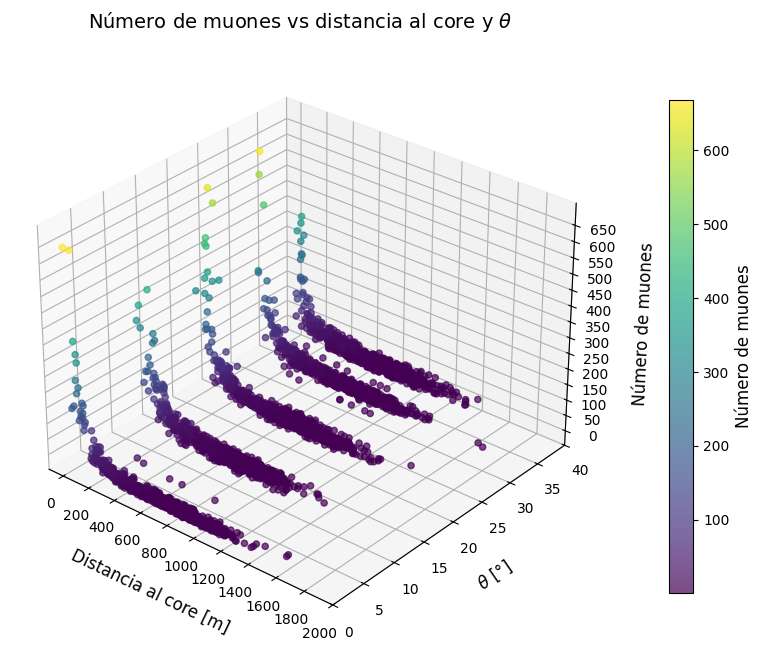

In [53]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Scatter
sc = ax.scatter(
    df_all_theta_r["r_core"],
    df_all_theta_r["theta"],
    df_all_theta_r["nMuones"],
    c=df_all_theta_r["nMuones"], cmap="viridis", alpha=0.7
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel(r"$\theta$ [°]", fontsize=12, labelpad=10)
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title(r"Número de muones vs distancia al core y $\theta$", fontsize=14, pad=20)

# Mejorar ticks
ax.set_xticks(np.arange(0, 2000+1, 200))  # ajustar según rango de r_core
ax.set_yticks(np.arange(0, 40+1, 5))      # ajustar según rango de theta
ax.set_ylim(0,40)
ax.set_zticks(np.arange(0, df_all_theta_r["nMuones"].max()+1, 50))  # ejemplo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=310)  # ajustar según conveniencia

# Grid
ax.grid(True)

plt.show()

### Comparación de energía MC vs REC

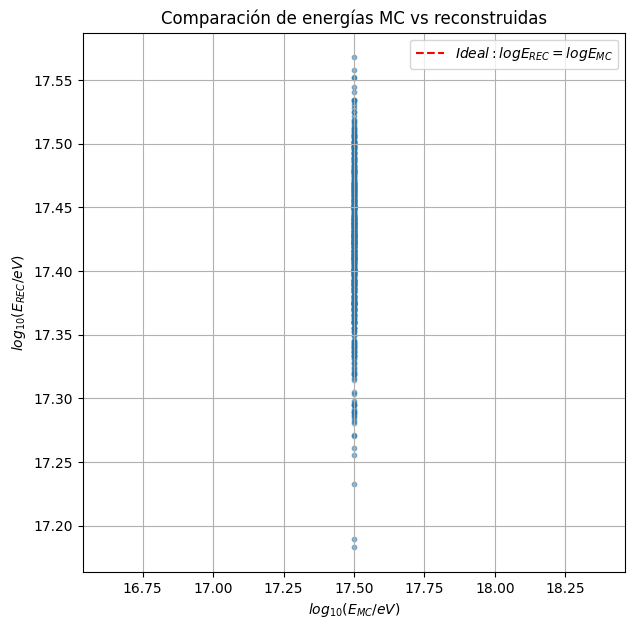

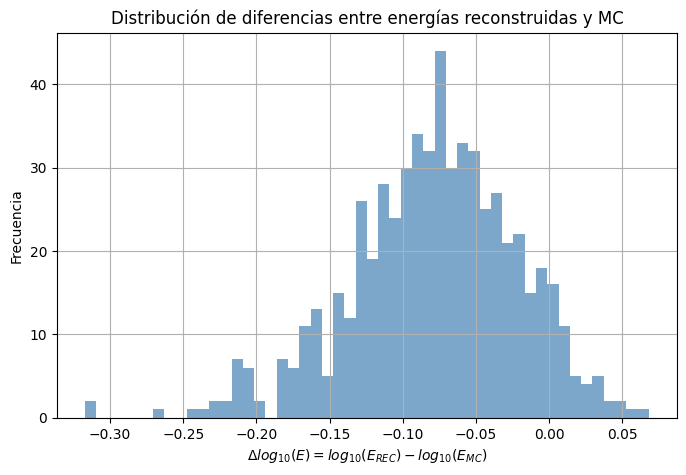

Promedio de ΔlogE: -0.07914192039720085
Desviación estándar de ΔlogE: 0.05742949974907103
Máximo |ΔlogE|: 0.31700217412075204


In [21]:
# -------------------------------
# Comparar logE_MC vs logE_REC
# -------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(df_all["logE_MC"], df_all["logE_REC"], s=10, alpha=0.5)
plt.plot([df_all["logE_MC"].min(), df_all["logE_MC"].max()],
         [df_all["logE_MC"].min(), df_all["logE_MC"].max()],
         'r--', label=r"$Ideal: logE_{REC} = logE_{MC}$")

plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$log_{10}(E_{REC} / eV)$")
plt.title("Comparación de energías MC vs reconstruidas")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Diferencia ΔlogE = logE_REC - logE_MC
# -------------------------------
deltaE = df_all["logE_REC"] - df_all["logE_MC"]

plt.figure(figsize=(8, 5))
plt.hist(deltaE, bins=50, alpha=0.7, color='steelblue')
plt.xlabel(r"$\Delta log_{10}(E) = log_{10}(E_{REC}) - log_{10}(E_{MC})$")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias entre energías reconstruidas y MC")
plt.grid(True)
plt.show()

# -------------------------------
# Métricas resumen
# -------------------------------
print("Promedio de ΔlogE:", np.mean(deltaE))
print("Desviación estándar de ΔlogE:", np.std(deltaE))
print("Máximo |ΔlogE|:", np.max(np.abs(deltaE)))

Sea la diferencia de energía en escala logarítmica:

$$
\Delta \log_{10} E = \log_{10}(E_{\text{rec}}) - \log_{10}(E_{\text{MC}}) = \log_{10}\!\left(\frac{E_{\text{rec}}}{E_{\text{MC}}}\right)
$$

Por lo tanto, la relación de energías se obtiene como:

$$
\frac{E_{\text{rec}}}{E_{\text{MC}}} = 10^{\Delta \log_{10} E}
$$

Para nuestro conjunto de datos:

- Promedio de $\Delta \log_{10} E$:

$$
\langle \Delta \log_{10} E \rangle \approx -0.079 \quad \Rightarrow \quad E_{\text{rec}} \approx 0.83 \times E_{\text{MC}}
$$

- Desviación estándar:

$$
\sigma(\Delta \log_{10} E) \approx 0.057 \quad \Rightarrow \quad \text{desvío típico en energía: } \pm 14\%
$$

- Máximo valor absoluto de la diferencia:

$$
|\Delta \log_{10} E|_{\text{max}} \approx 0.317 \quad \Rightarrow \quad \frac{E_{\text{rec}}}{E_{\text{MC}}} \approx 2.08
$$

**Conclusión:** en promedio, la reconstrucción de energía es bastante precisa, con una dispersión típica de ~15%.


### Comparaciones angulares MC vs REC

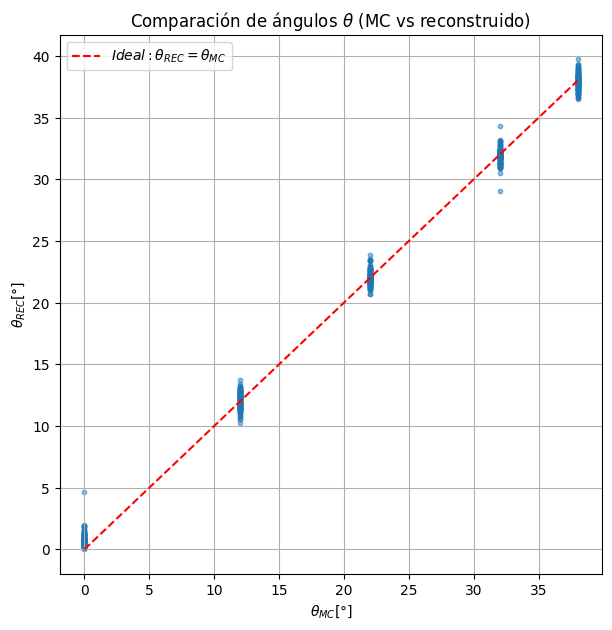

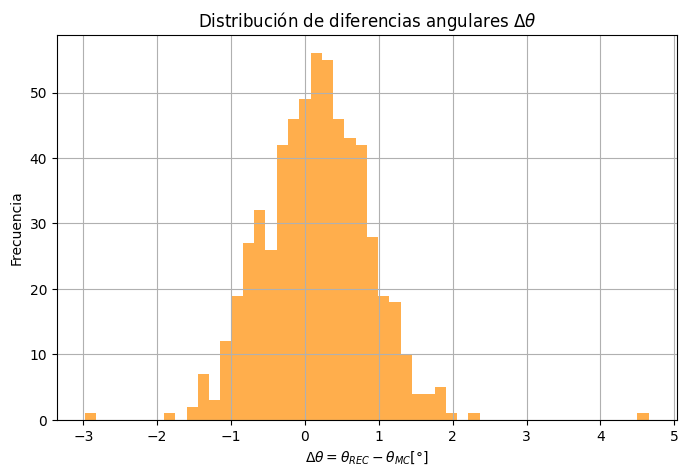

Promedio Δθ: 0.16042996676199114
Desviación estándar Δθ: 0.7087960778995519
Máximo |Δθ|: 4.653664007734509


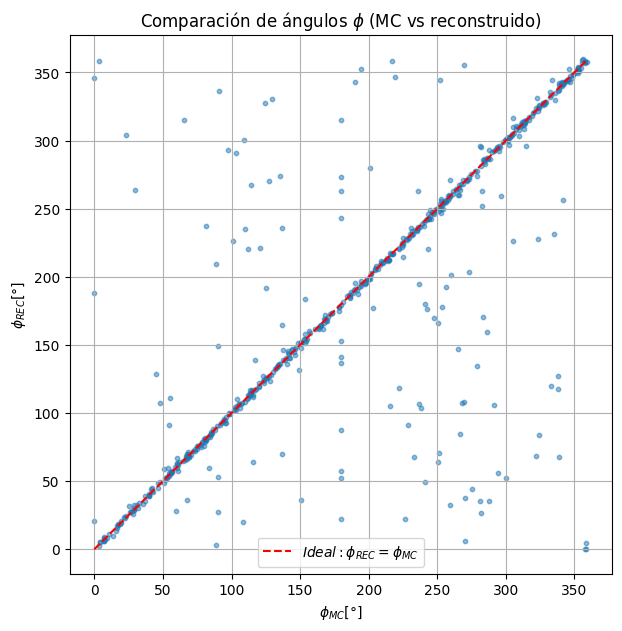

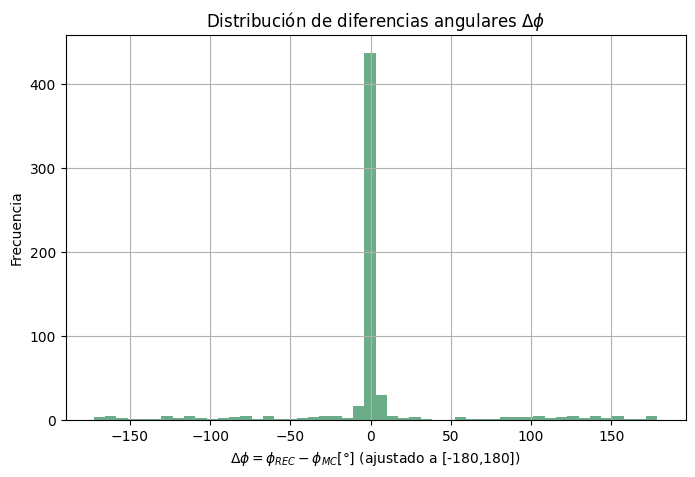

Promedio Δφ: 0.8387581512219282
Desviación estándar Δφ: 47.571903814739706
Máximo |Δφ|: 178.77173215854054


In [24]:
# -------------------------------
# THETA
# -------------------------------
plt.figure(figsize=(7,7))
plt.scatter(df_all["theta_MC"], df_all["theta_REC"], s=10, alpha=0.5)
plt.plot([df_all["theta_MC"].min(), df_all["theta_MC"].max()],
         [df_all["theta_MC"].min(), df_all["theta_MC"].max()],
         'r--', label=r"$Ideal: \theta_{REC} = \theta_{MC}$")
plt.xlabel(r"$\theta_{MC} [°]$")
plt.ylabel(r"$\theta_{REC} [°]$")
plt.title(r"Comparación de ángulos $\theta$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

delta_theta = df_all["theta_REC"] - df_all["theta_MC"]

plt.figure(figsize=(8,5))
plt.hist(delta_theta, bins=50, alpha=0.7, color='darkorange')
plt.xlabel(r"$\Delta \theta = \theta_{REC} - \theta_{MC} [°]$")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \theta$")
plt.grid(True)
plt.show()

print("Promedio Δθ:", np.mean(delta_theta))
print("Desviación estándar Δθ:", np.std(delta_theta))
print("Máximo |Δθ|:", np.max(np.abs(delta_theta)))


# -------------------------------
# PHI
# -------------------------------
plt.figure(figsize=(7,7))
plt.scatter(df_all["phi_MC"], df_all["phi_REC"], s=10, alpha=0.5)
plt.plot([df_all["phi_MC"].min(), df_all["phi_MC"].max()],
         [df_all["phi_MC"].min(), df_all["phi_MC"].max()],
         'r--', label=r"$Ideal: \phi_{REC} = \phi_{MC}$")
plt.xlabel(r"$\phi_{MC} [°]$")
plt.ylabel(r"$\phi_{REC} [°]$")
plt.title(r"Comparación de ángulos $\phi$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# Cuidar el wrap-around de phi (0–360)
delta_phi = (df_all["phi_REC"] - df_all["phi_MC"] + 180) % 360 - 180

plt.figure(figsize=(8,5))
plt.hist(delta_phi, bins=50, alpha=0.7, color='seagreen')
plt.xlabel(r"$\Delta \phi = \phi_{REC} - \phi_{MC} [°]$ (ajustado a [-180,180])")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \phi$")
plt.grid(True)
plt.show()

print("Promedio Δφ:", np.mean(delta_phi))
print("Desviación estándar Δφ:", np.std(delta_phi))
print("Máximo |Δφ|:", np.max(np.abs(delta_phi)))


Sea la diferencia de ángulo:

$$
\Delta \theta = \theta_{\text{rec}} - \theta_{\text{MC}}, \quad
\Delta \phi = \phi_{\text{rec}} - \phi_{\text{MC}}
$$

Para nuestro conjunto de datos:

#### Ángulo cenital $\theta$

- Promedio: 
$$
\langle \Delta \theta \rangle \approx 0.16^\circ
$$
- Desviación estándar: 
$$
\sigma(\Delta \theta) \approx 0.71^\circ
$$
- Máximo valor absoluto:
$$
|\Delta \theta|_{\text{max}} \approx 4.65^\circ
$$

**Interpretación:** la reconstrucción de $\theta$ es muy precisa. Se observan claramente los 5 clusters angulares de los datos simulados.

#### Ángulo azimutal $\phi$

- Promedio:
$$
\langle \Delta \phi \rangle \approx 0.84^\circ
$$
- Desviación estándar:
$$
\sigma(\Delta \phi) \approx 47.57^\circ
$$
- Máximo valor absoluto:
$$
|\Delta \phi|_{\text{max}} \approx 178.77^\circ
$$

**Interpretación:** aunque la mayoría de los puntos tienen buena coincidencia en $\phi$, hay algunos eventos que presentan errores muy grandes. Esto indica que la reconstrucción de $\phi$ es generalmente correcta, pero con outliers significativos que podrían necesitar filtrado.


In [17]:
# Calculamos diferencias
delta_logE = df_all["logE_REC"] - df_all["logE_MC"]
delta_theta = df_all["theta_REC"] - df_all["theta_MC"]
delta_phi = df_all["phi_REC"] - df_all["phi_MC"]

# Normalizar Δφ al rango [-180, 180]
delta_phi = (delta_phi + 180) % 360 - 180

# Mediana y MAD de Δφ
median_phi = np.median(delta_phi)
mad_phi = np.median(np.abs(delta_phi - median_phi))

# Resumen
print("=== Energía (log10) ===")
print(f"Promedio ΔlogE: {delta_logE.mean():.4f}")
print(f"Desviación estándar ΔlogE: {delta_logE.std():.4f}")
print(f"Máximo |ΔlogE|: {np.max(np.abs(delta_logE)):.4f}\n")

print("=== Ángulo cenital θ ===")
print(f"Promedio Δθ: {delta_theta.mean():.4f}°")
print(f"Desviación estándar Δθ: {delta_theta.std():.4f}°")
print(f"Máximo |Δθ|: {np.max(np.abs(delta_theta)):.4f}°\n")

print("=== Ángulo azimutal φ ===")
print(f"Mediana Δφ: {median_phi:.4f}°")
print(f"MAD Δφ: {mad_phi:.4f}°")
print(f"Máximo |Δφ|: {np.max(np.abs(delta_phi)):.4f}°")


=== Energía (log10) ===
Promedio ΔlogE: -0.0791
Desviación estándar ΔlogE: 0.0575
Máximo |ΔlogE|: 0.3170

=== Ángulo cenital θ ===
Promedio Δθ: 0.1604°
Desviación estándar Δθ: 0.7094°
Máximo |Δθ|: 4.6537°

=== Ángulo azimutal φ ===
Mediana Δφ: 0.0845°
MAD Δφ: 1.3090°
Máximo |Δφ|: 178.7717°


#### Análisis angular: métrica robusta para el ángulo azimutal $\phi$

Cuando comparamos los valores reconstruidos de $\phi$ con los del MC, observamos que usando la **desviación estándar** tradicionales obtenemos:

- Desviación estándar: $\sigma(\Delta \phi) \approx 47.57^\circ$

A primera vista, esto podría sugerir que las reconstrucciones de $\phi$ son muy imprecisas. Sin embargo, este resultado está fuertemente afectado por **outliers extremos**, es decir, unos pocos eventos que fallan completamente y tienen errores cercanos a $\pm 180^\circ$.

Para evaluar la **tendencia central y la dispersión típica** de manera más robusta usamos:

1. **Mediana**: valor central de la distribución de $\Delta \phi$, menos sensible a outliers $\Rightarrow$ Mediana: $\Delta \phi = 0.0845^\circ$  




2. **MAD (Median Absolute Deviation)**: desviación absoluta respecto de la mediana, también robusta frente a valores extremos $\Rightarrow$ MAD $\Delta \phi = 1.309^\circ$  

Usando estas métricas, podemos ver que **la mayoría de los eventos tienen $\phi$ reconstruido correctamente**, y que los datos no son tan malos como indicaría la desviación estándar clásica.  

En otras palabras, la mediana y el MAD nos permiten ver el **comportamiento típico** de los detectores, ignorando los pocos eventos con errores enormes que distorsionan la std convencional.

### Mapas de Muones

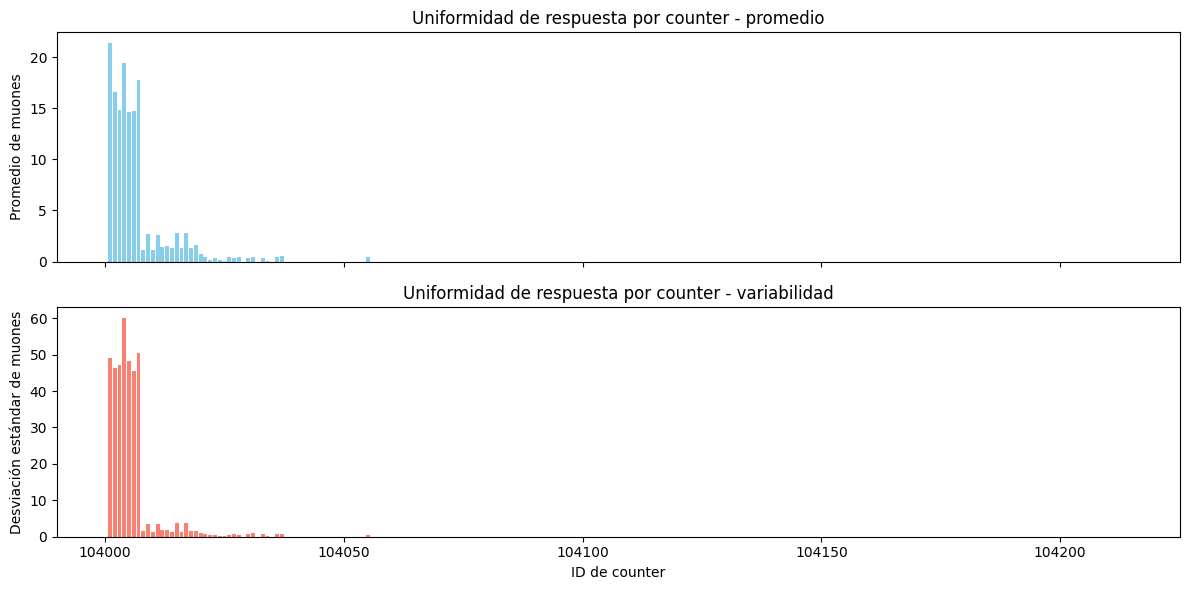

In [34]:
# -------------------------------
# Inicializamos diccionarios
# -------------------------------
counter_muones = {}    # acumulamos lista de muones por counter
counter_counts = {}    # cantidad de eventos por counter

for umdList in df_all['umdCounters']:
    for c in umdList:
        cid = c['counterId']
        nMu = c['nMuones']
        if nMu is None:
            continue
        counter_muones.setdefault(cid, []).append(nMu)
        counter_counts[cid] = counter_counts.get(cid, 0) + 1

# -------------------------------
# Calculamos estadísticos
# -------------------------------
counter_avg = {cid: np.mean(vals) for cid, vals in counter_muones.items()}
counter_std = {cid: np.std(vals) for cid, vals in counter_muones.items()}

# -------------------------------
# Visualización
# -------------------------------
counters_sorted = sorted(counter_avg.keys())
avg_vals = [counter_avg[cid] for cid in counters_sorted]
std_vals = [counter_std[cid] for cid in counters_sorted]

fig, axs = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# Promedio
axs[0].bar(counters_sorted, avg_vals, color='skyblue')
axs[0].set_ylabel("Promedio de muones")
axs[0].set_title("Uniformidad de respuesta por counter - promedio")

# Desviación estándar
axs[1].bar(counters_sorted, std_vals, color='salmon')
axs[1].set_ylabel("Desviación estándar de muones")
axs[1].set_xlabel("ID de counter")
axs[1].set_title("Uniformidad de respuesta por counter - variabilidad")

plt.tight_layout()
plt.show()


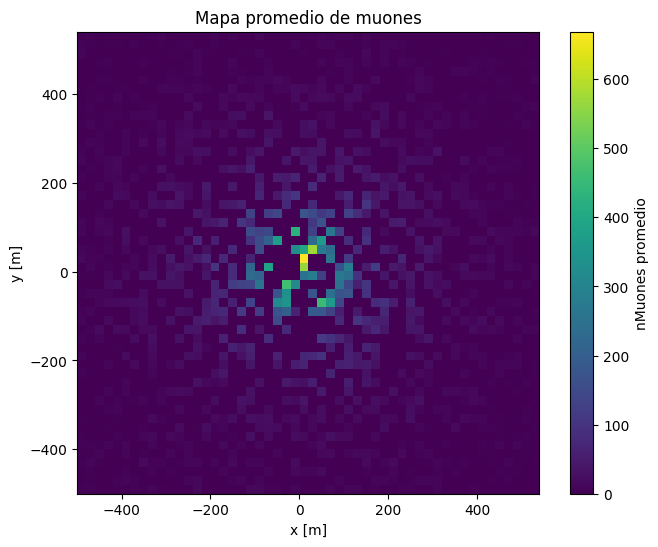

In [33]:
# Definir grilla
x_bins = np.arange(-500, 500+50, 20)
y_bins = np.arange(-500, 500+50, 20)
Z = np.zeros((len(x_bins)-1, len(y_bins)-1))
counts = np.zeros_like(Z)

# Llenar grilla
for umdList in df_all['umdCounters']:
    for c in umdList:
        if c['x_plane'] is None or c['y_plane'] is None:
            continue
        xi = np.digitize(c['x_plane'], x_bins)-1
        yi = np.digitize(c['y_plane'], y_bins)-1
        if 0 <= xi < Z.shape[0] and 0 <= yi < Z.shape[1]:
            Z[xi, yi] += c['nMuones']
            counts[xi, yi] += 1

# Promedio
Z_avg = np.divide(Z, counts, out=np.zeros_like(Z), where=counts!=0)

# Plot
plt.figure(figsize=(8,6))
plt.imshow(Z_avg.T, origin='lower', 
           extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
           cmap='viridis')
plt.colorbar(label='nMuones promedio')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Mapa promedio de muones')
plt.show()


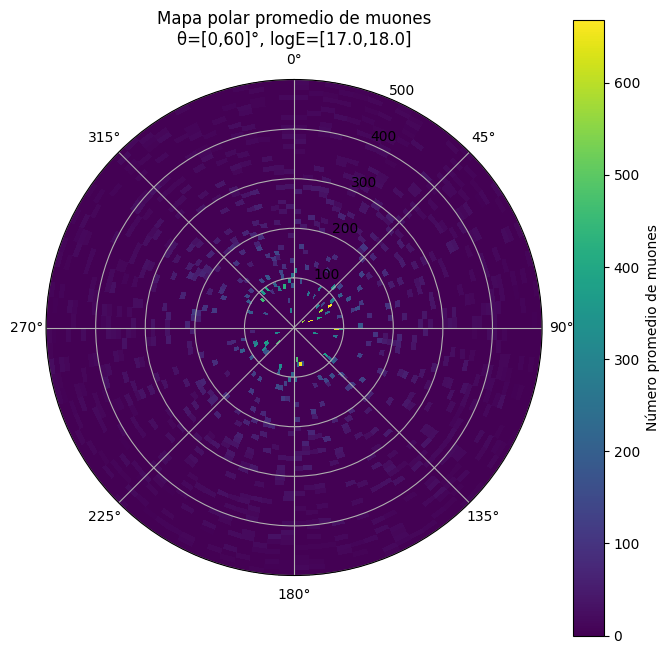

In [38]:
# -------------------------------
# Parámetros de binning
# -------------------------------
r_max = 500          # máxima distancia al core [m]
r_bin_size = 10       # tamaño del bin radial
phi_bins = 100        # cantidad de bins en phi

r_bins = np.arange(0, r_max + r_bin_size, r_bin_size)
phi_edges = np.linspace(0, 2*np.pi, phi_bins + 1)

# Filtros opcionales
theta_min, theta_max = 0, 60          # rango de θ para filtrar [°]
logE_min, logE_max = 17.0, 18.0       # rango de energía log10(E/ eV)

# -------------------------------
# Inicializar matrices
# -------------------------------
Z = np.zeros((len(phi_edges)-1, len(r_bins)-1))
counts = np.zeros_like(Z)

# -------------------------------
# Llenado de la grilla
# -------------------------------
for event_idx, umdList in enumerate(df_all['umdCounters']):
    # Filtro por θ y energía
    theta = df_all.loc[event_idx, 'theta_REC']
    logE = df_all.loc[event_idx, 'logE_REC']
    if not (theta_min <= theta <= theta_max and logE_min <= logE <= logE_max):
        continue

    for c in umdList:
        if c['r_core'] is None or c['nMuones'] is None:
            continue

        # Índices de bin
        r_idx = np.digitize(c['r_core'], r_bins) - 1
        phi = np.arctan2(c['y_plane'], c['x_plane'])
        phi = phi % (2*np.pi)   # ahora φ está entre 0 y 2π
        phi_idx = np.digitize(phi, phi_edges) - 1

        if 0 <= r_idx < Z.shape[1] and 0 <= phi_idx < Z.shape[0]:
            Z[phi_idx, r_idx] += c['nMuones']
            counts[phi_idx, r_idx] += 1

# -------------------------------
# Promedio de muones por bin
# -------------------------------
Z_avg = np.divide(Z, counts, out=np.zeros_like(Z), where=counts!=0)

# -------------------------------
# Plot polar
# -------------------------------
R, Phi = np.meshgrid(r_bins, phi_edges)

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
c = ax.pcolormesh(Phi, R, Z_avg, cmap='viridis')
ax.set_theta_zero_location("N")   # 0° arriba
ax.set_theta_direction(-1)        # sentido horario
ax.set_rlim(0, r_max)
fig.colorbar(c, ax=ax, label="Número promedio de muones")
plt.title(f"Mapa polar promedio de muones\nθ=[{theta_min},{theta_max}]°, logE=[{logE_min},{logE_max}]")
plt.show()


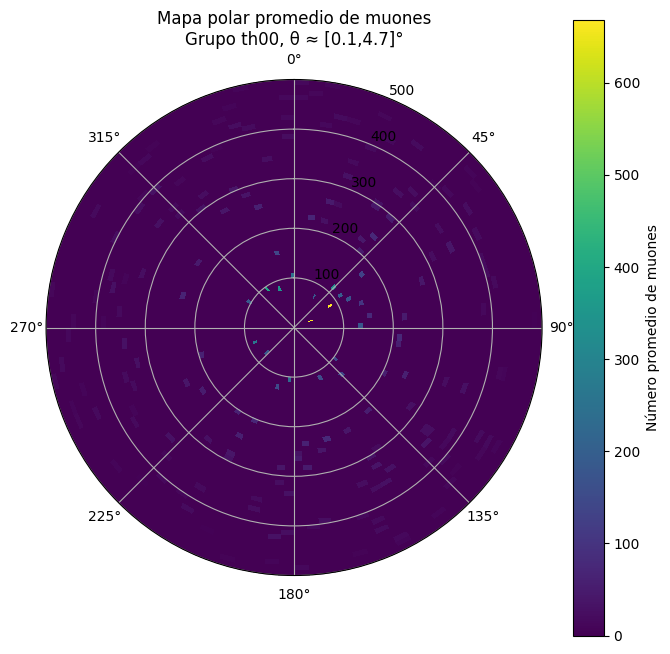

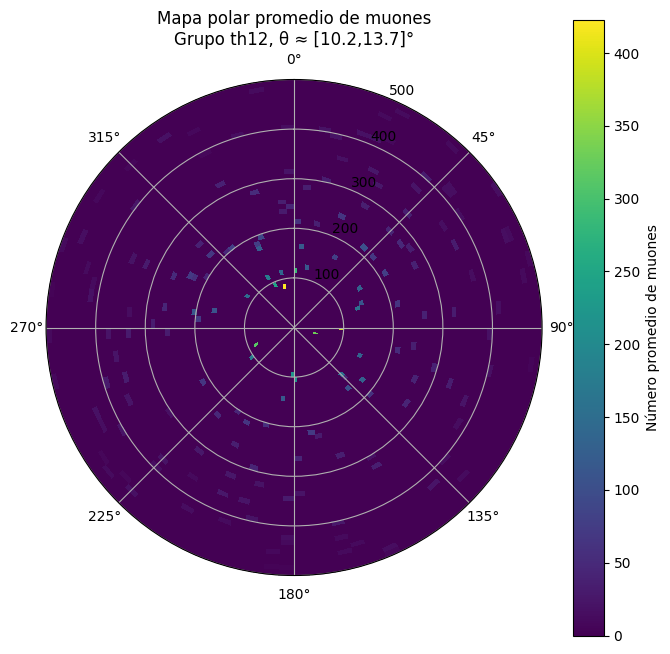

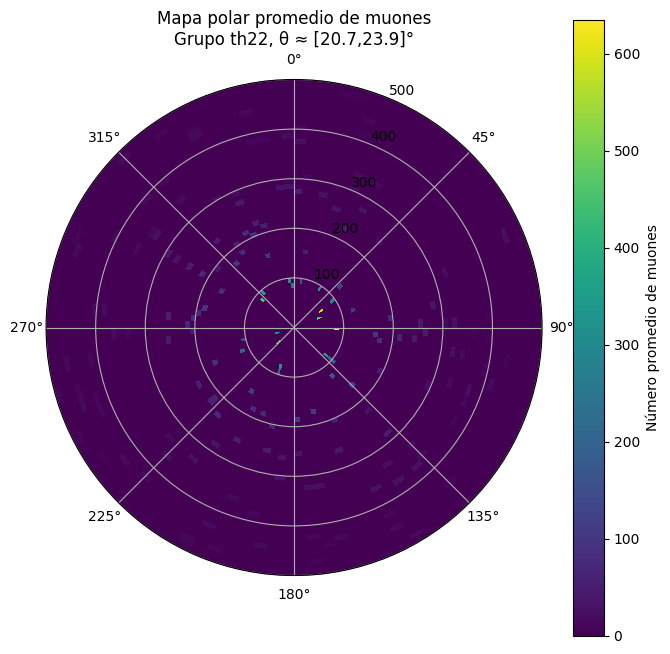

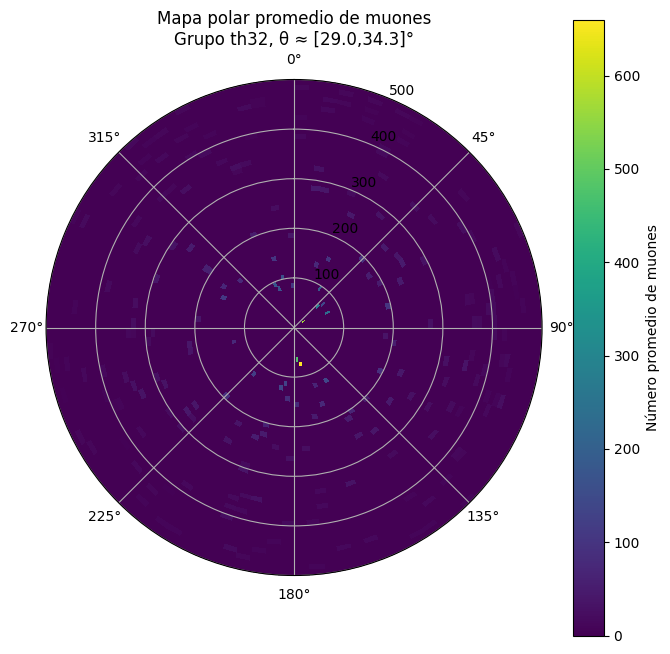

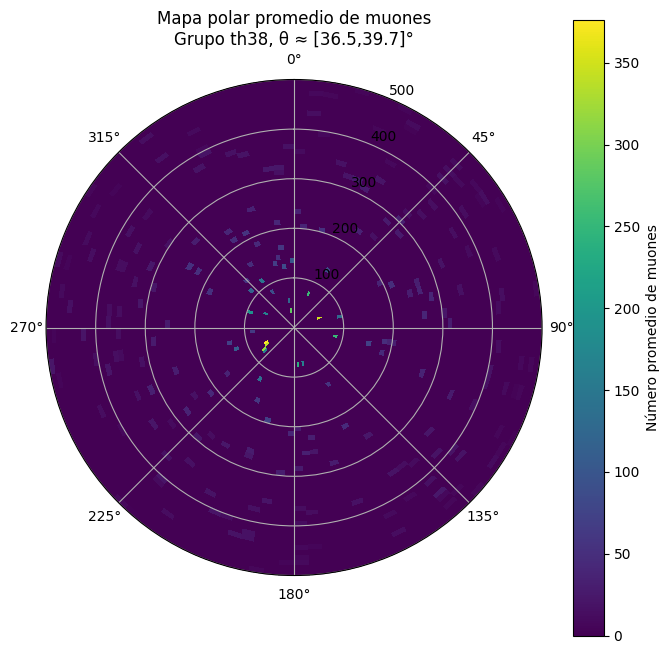

In [55]:
# -------------------------------
# Parámetros de binning
# -------------------------------
r_max = 500          # máxima distancia al core [m]
r_bin_size = 10       # tamaño del bin radial
phi_bins = 100        # cantidad de bins en phi

r_bins = np.arange(0, r_max + r_bin_size, r_bin_size)
phi_edges = np.linspace(0, 2*np.pi, phi_bins + 1)

# -------------------------------
# Iterar sobre cada grupo de th
# -------------------------------
for th_group in df_all['th'].unique():
    df_th = df_all[df_all['th'] == th_group]
    
    # Calcular rango real de theta en este grupo
    theta_min_real = df_th['theta_REC'].min()
    theta_max_real = df_th['theta_REC'].max()
    
    # Inicializar matrices
    Z = np.zeros((len(phi_edges)-1, len(r_bins)-1))
    counts = np.zeros_like(Z)

    # Llenado de la grilla
    for event_idx, umdList in enumerate(df_th['umdCounters']):
        for c in umdList:
            if c['r_core'] is None or c['nMuones'] is None:
                continue

            # Índices de bin
            r_idx = np.digitize(c['r_core'], r_bins) - 1
            phi = np.arctan2(c['y_plane'], c['x_plane']) % (2*np.pi)
            phi_idx = np.digitize(phi, phi_edges) - 1

            if 0 <= r_idx < Z.shape[1] and 0 <= phi_idx < Z.shape[0]:
                Z[phi_idx, r_idx] += c['nMuones']
                counts[phi_idx, r_idx] += 1

    # Promedio de muones por bin
    Z_avg = np.divide(Z, counts, out=np.zeros_like(Z), where=counts!=0)

    # -------------------------------
    # Plot polar
    # -------------------------------
    R, Phi = np.meshgrid(r_bins, phi_edges)

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    c = ax.pcolormesh(Phi, R, Z_avg, cmap='viridis')
    ax.set_theta_zero_location("N")   # 0° arriba
    ax.set_theta_direction(-1)        # sentido horario
    ax.set_rlim(0, r_max)
    fig.colorbar(c, ax=ax, label="Número promedio de muones")
    plt.title(f"Mapa polar promedio de muones\nGrupo {th_group}, θ ≈ [{theta_min_real:.1f},{theta_max_real:.1f}]°")
    plt.show()